### Introduction

Healthcare data plays an important role in understanding patient health and medical conditions. By analyzing this data, we can identify common health patterns and important trends.

In this project, Exploratory Data Analysis (EDA) is performed on a healthcare dataset to study patient information such as age, gender, and health indicators. The analysis helps in understanding the structure of the data, finding meaningful relationships, and detecting important insights.

These insights can be useful for improving healthcare planning and supporting better patient care.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df=pd.read_csv("C:\\Users\\laksh\\Downloads\\healthcare_dataset.csv\\healthcare_dataset.csv")

In [3]:
print(df.head())

                  Name  Age  Gender Blood Type Medical Condition  \
0      Tiffany Ramirez   81  Female         O-          Diabetes   
1          Ruben Burns   35    Male         O+            Asthma   
2            Chad Byrd   61    Male         B-           Obesity   
3    Antonio Frederick   49    Male         B-            Asthma   
4  Mrs. Brandy Flowers   51    Male         O-         Arthritis   

  Date of Admission          Doctor                   Hospital  \
0        2022-11-17  Patrick Parker           Wallace-Hamilton   
1        2023-06-01   Diane Jackson  Burke, Griffin and Cooper   
2        2019-01-09      Paul Baker                 Walton LLC   
3        2020-05-02  Brian Chandler                 Garcia Ltd   
4        2021-07-09  Dustin Griffin    Jones, Brown and Murray   

  Insurance Provider  Billing Amount  Room Number Admission Type  \
0           Medicare    37490.983364          146       Elective   
1   UnitedHealthcare    47304.064845          404      Eme

In [4]:
print(df.tail())

                      Name  Age  Gender Blood Type Medical Condition  \
9995            James Hood   83    Male         A+           Obesity   
9996       Stephanie Evans   47  Female        AB+         Arthritis   
9997  Christopher Martinez   54    Male         B-         Arthritis   
9998           Amanda Duke   84    Male         A+         Arthritis   
9999             Eric King   20    Male         B-         Arthritis   

     Date of Admission             Doctor                   Hospital  \
9995        2022-07-29       Samuel Moody   Wood, Martin and Simmons   
9996        2022-01-06  Christopher Yates               Nash-Krueger   
9997        2022-07-01   Robert Nicholson            Larson and Sons   
9998        2020-02-06        Jamie Lewis               Wilson-Lyons   
9999        2023-03-22        Tasha Avila  Torres, Young and Stewart   

     Insurance Provider  Billing Amount  Room Number Admission Type  \
9995   UnitedHealthcare    39606.840083          110       Elec

In [5]:
print(df.isna().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [8]:
print(df.describe())

                Age  Billing Amount   Room Number
count  10000.000000    10000.000000  10000.000000
mean      51.452200    25516.806778    300.082000
std       19.588974    14067.292709    115.806027
min       18.000000     1000.180837    101.000000
25%       35.000000    13506.523967    199.000000
50%       52.000000    25258.112566    299.000000
75%       68.000000    37733.913727    400.000000
max       85.000000    49995.902283    500.000000


### Outlier Detection

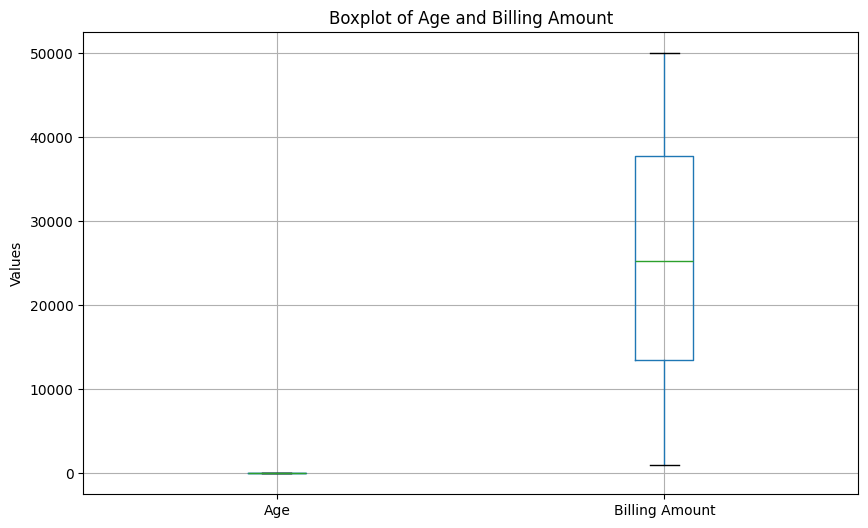

In [40]:
# Boxplot to identify outliers in key numeric healthcare features
plt.figure(figsize=(10,6))
df[['Age', 'Billing Amount']].boxplot()
plt.title("Boxplot of Age and Billing Amount")
plt.ylabel("Values")
plt.show()


1.Which age groups are most frequently admitted to the hospital

In [10]:
age_bins = [0, 17, 35, 55, 100]
age_labels = ['Under 18', '18–35', '36–55', '56+']

df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

In [11]:
age_group_counts = df['Age_Group'].value_counts().sort_index()
age_group_counts


Age_Group
Under 18       0
18–35       2654
36–55       2902
56+         4444
Name: count, dtype: int64

In [12]:
most_admitted = age_group_counts.idxmax()
most_admitted


'56+'

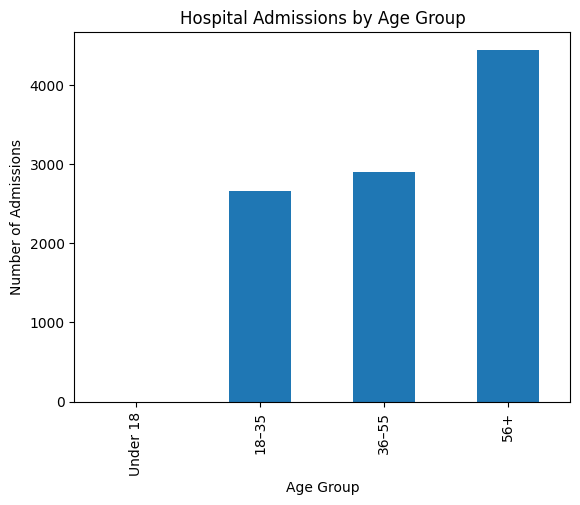

In [13]:
age_group_counts.plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Number of Admissions')
plt.title('Hospital Admissions by Age Group')
plt.show()


2.What are the most prevalent medical conditions among patients aged 56 and above

In [14]:
elderly_df = df[df['Age'] >= 56]
elderly_df['Medical Condition'].value_counts()

Medical Condition
Cancer          767
Asthma          749
Diabetes        742
Arthritis       733
Hypertension    727
Obesity         726
Name: count, dtype: int64

3.Does admission type influence billing amount

In [15]:
df.groupby('Admission Type')['Billing Amount'].mean()

Admission Type
Elective     25891.832668
Emergency    24708.511933
Urgent       25960.833557
Name: Billing Amount, dtype: float64

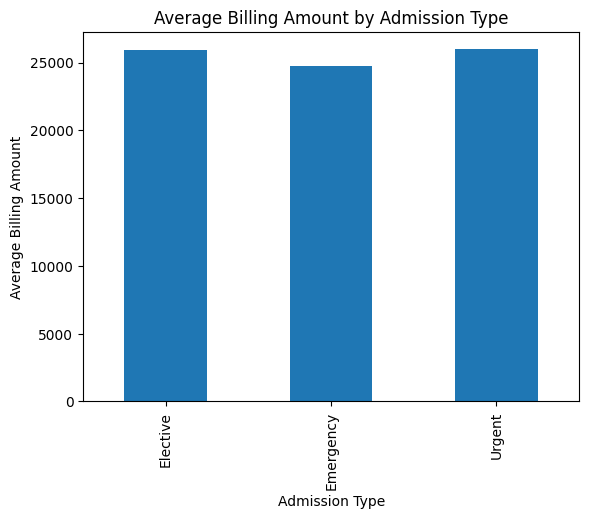

In [16]:
df.groupby('Admission Type')['Billing Amount'].mean().plot(kind='bar')
plt.title('Average Billing Amount by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Average Billing Amount')
plt.show()

4.Which medical conditions are associated with higher average billing amounts

In [17]:
df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)


Medical Condition
Diabetes        26060.116129
Obesity         25720.842683
Cancer          25539.096133
Asthma          25416.869895
Hypertension    25198.033973
Arthritis       25187.631255
Name: Billing Amount, dtype: float64

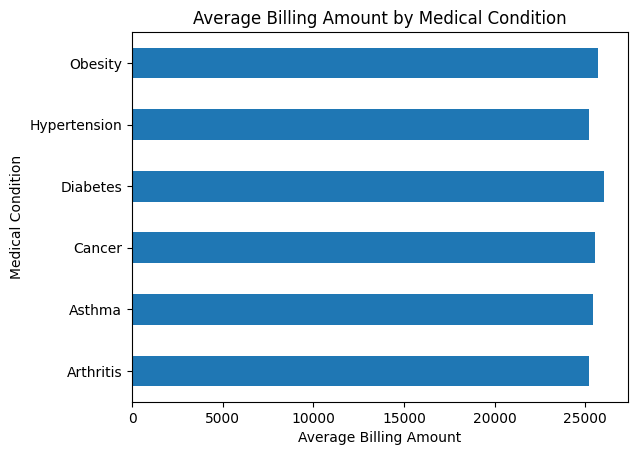

In [18]:
df.groupby('Medical Condition')['Billing Amount'].mean().plot(kind='barh')
plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Average Billing Amount')
plt.ylabel('Medical Condition')
plt.show()


5.Does the billing amount vary by insurance provider

In [19]:
df.groupby('Insurance Provider')['Billing Amount'].mean()

Insurance Provider
Aetna               25837.923338
Blue Cross          25652.489617
Cigna               25656.946859
Medicare            25002.480429
UnitedHealthcare    25404.685388
Name: Billing Amount, dtype: float64

6.How do hospital admissions vary over time

In [20]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])

In [21]:
df['Date of Admission'].dt.month.value_counts().sort_index()

Date of Admission
1     837
2     778
3     850
4     841
5     842
6     833
7     827
8     845
9     801
10    883
11    820
12    843
Name: count, dtype: int64

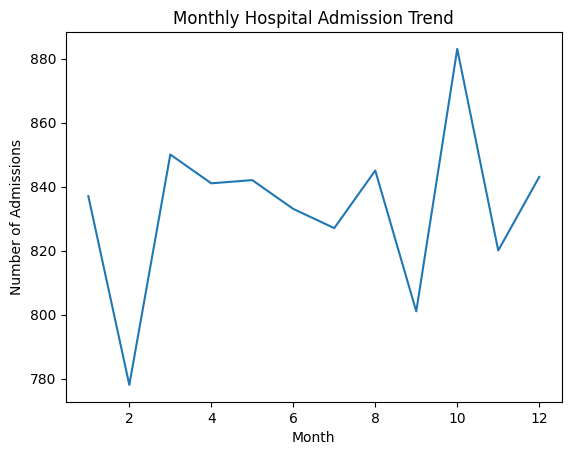

In [22]:
df['Date of Admission'].dt.month.value_counts().sort_index().plot(kind='line') 
plt.title('Monthly Hospital Admission Trend') 
plt.xlabel('Month') 
plt.ylabel('Number of Admissions') 
plt.show()

7.How long do patients typically stay in the hospital

In [23]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

df['Length_of_Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

In [24]:
df['Length_of_Stay'].mean() 


np.float64(15.5618)

In [25]:
df['Length_of_Stay'].median()


np.float64(16.0)

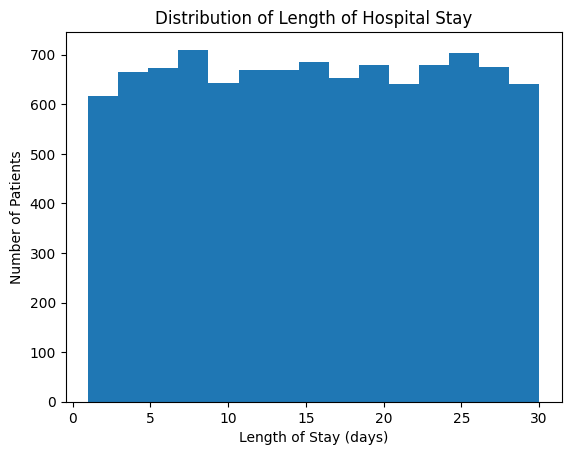

In [26]:
df['Length_of_Stay'].plot(kind='hist', bins=15)
plt.title('Distribution of Length of Hospital Stay')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Number of Patients')
plt.show()


8. Which gender is admitted to the hospital more frequently

In [27]:
df['Gender'].value_counts()


Gender
Female    5075
Male      4925
Name: count, dtype: int64

9. Which medical conditions are most commonly diagnosed among patients

In [28]:
df['Medical Condition'].value_counts()


Medical Condition
Asthma          1708
Cancer          1703
Hypertension    1688
Arthritis       1650
Obesity         1628
Diabetes        1623
Name: count, dtype: int64

10. What is the distribution of billing amounts among patients

In [29]:
df['Billing Amount'].describe()

count    10000.000000
mean     25516.806778
std      14067.292709
min       1000.180837
25%      13506.523967
50%      25258.112566
75%      37733.913727
max      49995.902283
Name: Billing Amount, dtype: float64

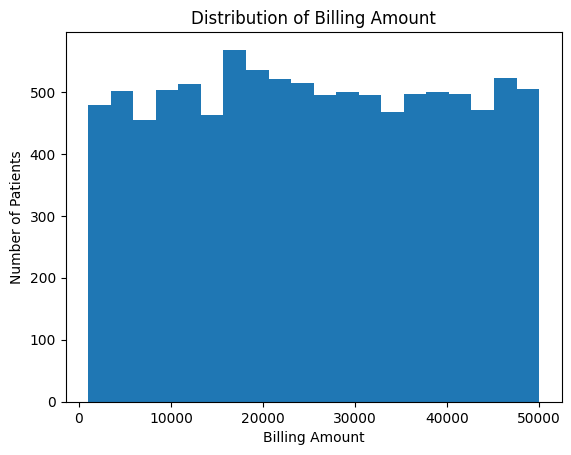

In [30]:
df['Billing Amount'].plot(kind='hist', bins=20)
plt.title('Distribution of Billing Amount')
plt.xlabel('Billing Amount')
plt.ylabel('Number of Patients')
plt.show()


11. How does the length of hospital stay vary across different admission types

In [31]:
df.groupby('Admission Type')['Length_of_Stay'].mean()

Admission Type
Elective     15.601172
Emergency    15.609742
Urgent       15.476556
Name: Length_of_Stay, dtype: float64

12. Which medical conditions are associated with longer hospital stays on average

In [32]:
df.groupby('Medical Condition')['Length_of_Stay'].mean().sort_values(ascending=False)


Medical Condition
Arthritis       15.990303
Diabetes        15.574245
Asthma          15.481265
Cancer          15.479742
Hypertension    15.430095
Obesity         15.421990
Name: Length_of_Stay, dtype: float64

13. What is the distribution of billing amounts across different lengths of hospital stay

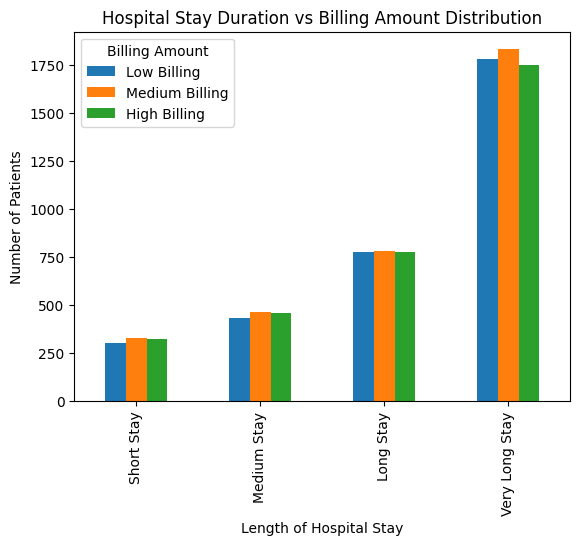

In [33]:
df['Stay_Category'] = pd.cut(
    df['Length_of_Stay'],
    bins=[0, 3, 7, 14, 30],
    labels=['Short Stay', 'Medium Stay', 'Long Stay', 'Very Long Stay']
)

df['Billing_Category'] = pd.cut(
    df['Billing Amount'],
    bins=3,
    labels=['Low Billing', 'Medium Billing', 'High Billing']
)

counts = df.groupby(['Stay_Category', 'Billing_Category']).size().unstack(fill_value=0)

counts.plot(kind='bar')

plt.title('Hospital Stay Duration vs Billing Amount Distribution')
plt.xlabel('Length of Hospital Stay')
plt.ylabel('Number of Patients')
plt.legend(title='Billing Amount')
plt.show()



14. Do older patients tend to have longer hospital stays

In [34]:
df[['Age', 'Length_of_Stay']].corr()

,Age,Length_of_Stay
Age,1.000000,0.009111
Length_of_Stay,0.009111,1.000000


15. Are emergency admissions associated with higher billing amounts compared to other admission types

In [35]:
df.groupby('Admission Type')['Billing Amount'].mean()

Admission Type
Elective     25891.832668
Emergency    24708.511933
Urgent       25960.833557
Name: Billing Amount, dtype: float64

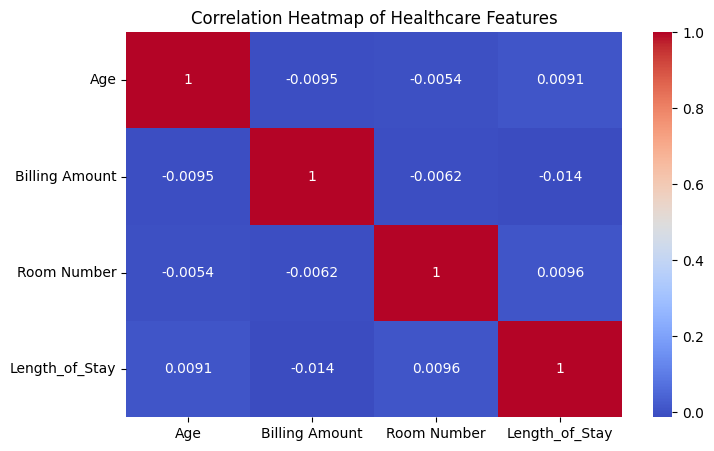

In [36]:
#Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Healthcare Features")
plt.show()

### Suggestions & Recommendations

1.Check patients with higher treatment costs
  
  Reviewing these cases can help manage expenses and improve planning.

2.Plan treatment based on age
  
  Patients of different ages may need different types of care.

3.Regularly check important health values
  
  Monitoring key health values can help identify problems early.

4.Maintain correct and clean records
  
  Proper data entry helps in getting accurate analysis results.

5.Use results to improve hospital services
  
  The findings from this analysis can support better patient care and decision-making.